# <span style="color:red"> QTM 151 - Quiz 5 </span>

### Submit as an **HTML file**
### Quiz is open 11:30am to 12:20pm

<font size = "4" >
This quiz is open book 

- You can use the lecture notes
- You will get partial credit for attempting the questions
- To get full credit, the code should work as intended
- You should <span style="color:red"> NOT </span> communicate with other students

Print the following message: <br>

"I will abide by Emory's code of conduct"

In [57]:
# Write your answer here

print("I will abide by Emory's code of conduct")

I will abide by Emory's code of conduct


In [58]:
# import necessary libraries
import pandas as pd

<font size = "5">

1. Replacing strings

<font size = "4">

- Read in the data from "yelp_reviews.csv", assigning the output to a DataFrame.

- This dataset contains a large number of restaurant reviews from yelp.com. The text of each review is stored in the "review" column.

- In the "review" column, do the following:

    - Replace all instances of the word "champaign" with "Champaign" (it is a proper noun, the name of a city in Illinois)
    - Replace all instances of the phrase "Champaign Urbana" with "Champaign-Urbana".

- Make sure the replacements you make are being applied to the original DataFrame.


In [59]:
df = pd.read_csv("data_quiz/yelp_reviews.csv")

In [60]:
# your code here
display(df["review"])
df["review"] = df["review"].str.replace("champaign", "Champaign")
df["review"] = df["review"].str.replace("Champaign Urbana", "Champaign-Urbana")

display(df["review"])


0        All I can say is they have very good ice cream...
1        Nice little local place for ice cream.My favor...
2        A delicious treat on a hot day! Staff was very...
3        This was great service and a fun crew! I got t...
4        This is one of my favorite places to get ice c...
                               ...                        
19890    Had the chocolate cannoli! The filling was ric...
19891    Love apricot croissant! I bought it at 4:00 PM...
19892    Line was about 25 people long. It went fast! T...
19893    Its hard not to order everything when I come h...
19894    Every mall needs an Eataly for real. La Pastic...
Name: review, Length: 19895, dtype: object

0        All I can say is they have very good ice cream...
1        Nice little local place for ice cream.My favor...
2        A delicious treat on a hot day! Staff was very...
3        This was great service and a fun crew! I got t...
4        This is one of my favorite places to get ice c...
                               ...                        
19890    Had the chocolate cannoli! The filling was ric...
19891    Love apricot croissant! I bought it at 4:00 PM...
19892    Line was about 25 people long. It went fast! T...
19893    Its hard not to order everything when I come h...
19894    Every mall needs an Eataly for real. La Pastic...
Name: review, Length: 19895, dtype: object

<font size = "5">

2. Look for reviews containing a string pattern

<font size = "4">

- Search for all reviews that contain a string describing a range of years, such as "1992-1998" or "2000-2007".

- Create a DataFrame called ``df_year`` that consists of all the rows of the original DataFrame for which you found a range of years in the Yelp review.

- We can characterize a range of years as: 4 digit characters, followed by a dash, followed by 4 digit characters.


In [61]:
# your code here
df_year = df["review"].str.contains("\d{4}-\d{4}") #boolean series
display(df_year)
print(df_year.sum())


df_year2 = df["review"].str.findall("\d{4}-\d{4}") #proper series that show the years
df_year2 = df_year2[df_year2.str.len() > 0]
display(df_year2)

0        False
1        False
2        False
3        False
4        False
         ...  
19890    False
19891    False
19892    False
19893    False
19894    False
Name: review, Length: 19895, dtype: bool

3


12240    [1987-1992]
14737    [1957-1958]
17759    [1950-1960]
Name: review, dtype: object

<font size = "5">

3. Find similarly spelled words

<font size = "4">

- Find all occurences of the words "place", "places", "plate", and "plates" in the reviews by using ``.str.findall`` **one time**. This should be in the form of a Pandas Series where each row is a list that either contains the found strings or is empty.

- Use the ``.str.len`` method to create a Pandas Series that only includes the rows where a match was found. (Put another way, the Series should exclude all the empty lists where no match was found)

In [68]:
# your code here

answer = df["review"].str.findall("pla[ct]es?")

answer = answer[answer.str.len() > 0]
display(answer)

print(type(answer))

1         [place]
4        [places]
5         [place]
6         [place]
7         [place]
           ...   
19871     [place]
19874     [place]
19879     [place]
19884     [place]
19887     [place]
Name: review, Length: 7511, dtype: object

<class 'pandas.core.series.Series'>


<font size = "5">

4. Find words ending with "y"

<font size = "4">

- Find all words ending with the letter "y" by using ``.str.findall``. This should be in the form of a Pandas Series where each row is a list that either contains the found strings or is empty.

- Specifically, you are looking for one or more consecutive alphabetical characters (both upper and lower case) or apostrophe (single quote) characters followed by the letter "y".

- In order to ensure that the word **ends** with "y", add the special character "\\\b" (two backslashes and a "b") immediately after the "y". This is called a word boundary.

- Use the ``.str.len`` method to create a Pandas Series that only includes the rows where a match was found. (Put another way, the Series should exclude all the empty lists where no match was found)



In [69]:
# your code here

answer2 = df["review"].str.findall("[A-Za-z']+y\\b")

ans3 = answer2[answer2.str.len() > 0]
display(ans3)

0                                  [say, they, very, very]
1                                        [My, My, usually]
2                                    [day, very, friendly]
3                             [freshly, only, pretty, icy]
4        [my, really, easy, Dairy, very, friendly, many...
                               ...                        
19890                              [flaky, crispy, greasy]
19891       [Normally, very, bakery, evenly, happy, happy]
19892                        [They, variety, Creamy, They]
19893                                 [delivery, They, my]
19894    [Every, Eataly, pastry, by, my, day, slightly,...
Name: review, Length: 19053, dtype: object

<font size = "5">

5. Convert reviews to individual words

<font size = "4">

- Add a new column to the DataFrame with the name "tokens", where each row of the column is a list containing all individual words appearing in the Yelp review for that row.

- For the purposes of this question, we will take a single word to be one or more consecutive occurrences of the letters, A-Z, a-z, and the apostrophe character.

- Then use ``.apply`` to ensure every word in the "tokens" column is lowercase. Make sure you are actually changing the "tokens" column of the DataFrame in this step.

- **Note:** There are no "NaNs" in the "review" column, so it shouldn't be necessary to account for the case where an entry in the "tokens" column isn't actually a list.

In [64]:
df["tokens1"] = df["review"].fillna("").str.lower().str.findall("[A-Za-z']+").apply(tuple)
display(df["tokens1"])
#does this work? i tried it yesterday night because i was not fully understanding the loop.
# but now i understood the loop, i still want to ask if this works or not

0        (all, i, can, say, is, they, have, very, good,...
1        (nice, little, local, place, for, ice, cream, ...
2        (a, delicious, treat, on, a, hot, day, staff, ...
3        (this, was, great, service, and, a, fun, crew,...
4        (this, is, one, of, my, favorite, places, to, ...
                               ...                        
19890    (had, the, chocolate, cannoli, the, filling, w...
19891    (love, apricot, croissant, i, bought, it, at, ...
19892    (line, was, about, people, long, it, went, fas...
19893    (its, hard, not, to, order, everything, when, ...
19894    (every, mall, needs, an, eataly, for, real, la...
Name: tokens1, Length: 19895, dtype: object

In [65]:
# your code here
df["tokens"] = df["review"].str.findall("[A-Za-z']+")

def lower_list(lst):
    out = []
    if not isinstance(lst, list):
        return tuple(out)
    for w in lst:
        out.append(w.lower())
    return tuple(out)

df["tokens"] = df["tokens"].apply(lower_list)
display(df["tokens"])

0        (all, i, can, say, is, they, have, very, good,...
1        (nice, little, local, place, for, ice, cream, ...
2        (a, delicious, treat, on, a, hot, day, staff, ...
3        (this, was, great, service, and, a, fun, crew,...
4        (this, is, one, of, my, favorite, places, to, ...
                               ...                        
19890    (had, the, chocolate, cannoli, the, filling, w...
19891    (love, apricot, croissant, i, bought, it, at, ...
19892    (line, was, about, people, long, it, went, fas...
19893    (its, hard, not, to, order, everything, when, ...
19894    (every, mall, needs, an, eataly, for, real, la...
Name: tokens, Length: 19895, dtype: object

<font size = "5">

6. Convert reviews to individual words

<font size = "4">

- Unravel the values from "tokens" into a single Pandas Series containing all the words appearing in every review.

- Then, create a new Pandas Series containing the probabilities/proportions of each word. This Pandas Series will have an index column (the tokens/words) and the single "proper" column will be the proportions/probabilities.

- Create a bar plot of the probabilities of the 13 most frequently occuring words in the dataset. Add a label to the y-axis and a title.

In [66]:
# your code here
import matplotlib.pyplot as plt

0.9999999999999999


tokens
the      0.051181
and      0.033378
i        0.028268
a        0.026318
to       0.022372
was      0.016261
of       0.015601
it       0.014410
is       0.013125
in       0.012075
for      0.010340
cream    0.009860
ice      0.009021
Name: proportion, dtype: float64

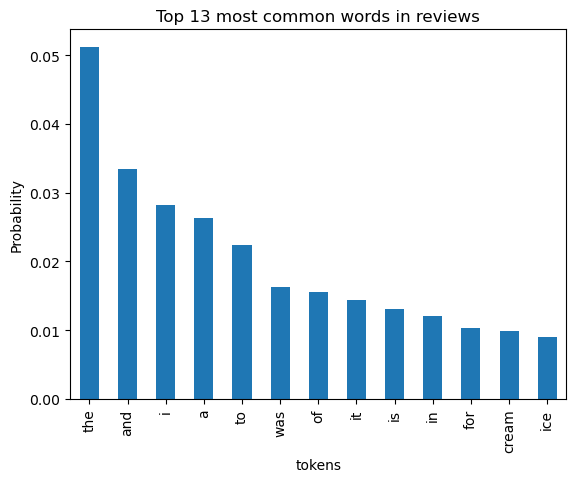

In [67]:
genre_appearances = df["tokens"].explode()
genre_probs = genre_appearances.value_counts(normalize = True)
print(genre_probs.sum())
plot1 = genre_probs.head(13)
display(plot1)

#ploting
plot1.plot(kind = "bar")
plt.title("Top 13 most common words in reviews")
plt.ylabel("Probability")
plt.show()